In [1]:
import random, numpy as np, torch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
# Uncomment this in Colab if needed:
!git clone https://github.com/blessthef4llen/Parking-Space-Detection.git
%cd Parking-Space-Detection

Cloning into 'Parking-Space-Detection'...
remote: Enumerating objects: 1031, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 1031 (delta 21), reused 9 (delta 3), pack-reused 989 (from 2)
Receiving objects: 100% (1031/1031), 46.06 MiB | 14.40 MiB/s, done.
Resolving deltas: 100% (48/48), done.
/content/Parking-Space-Detection


In [3]:
#Imports and paths
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

BASE_DIR = "."
CROPS_DIR = os.path.join(BASE_DIR, "data", "crops")

print(f"BASE_DIR: {BASE_DIR}")
print(f"CROPS_DIR: {CROPS_DIR}")
print(f"Exits: {os.path.isdir(CROPS_DIR)}")


Using device: cuda
BASE_DIR: .
CROPS_DIR: ./data/crops
Exits: True


In [4]:
#Datasets, Transformations and DataLoaders taken from previous notebook

img_size = 224

#image transformation
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_transfrom = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

#loading dataset and splitting for training and validation
full_dataset = datasets.ImageFolder(root=CROPS_DIR, transform=train_transform)
class_names = full_dataset.classes
print(f"Classes: {class_names}")
print(f"Total samples: {len(full_dataset)}")

val_ratio = 0.2
val_size = int(len(full_dataset)*val_ratio)
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transfrom

batch_size = 16

#loading data
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")

Classes: ['free_parking_space', 'not_free_parking_space', 'partially_free_parking_space']
Total samples: 903
Train samples: 723
Validation samples: 180


In [5]:
def build_resnet18_model(num_classes=3, freeze=True):

    #loads a pretrained ResNet18
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    #freezes the convolutional layers
    if freeze:
        for param in model.parameters():
            param.require_grad = False

    #Replace fully connected layer with our own classification head
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model

num_classes = len(class_names)
model_resnet = build_resnet18_model(num_classes=num_classes, freeze=True)
model_resnet.to(device)
print(model_resnet.fc)



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 118MB/s]


Linear(in_features=512, out_features=3, bias=True)


In [6]:
#loss function and optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_resnet.parameters(), lr=0.001)

num_epochs = 10

train_losses_resnet = []
val_accuracies_resnet = []


In [7]:
for epoch in range(num_epochs):
    model_resnet.train()
    train_loss = 0.0

    #TRAINGING LOOP
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_resnet(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    #VALIDATION LOOP
    model_resnet.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model_resnet(images)
            _, pred = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    epoch_loss = train_loss / len(train_loader)
    epoch_accuracy = correct / total

    train_losses_resnet.append(epoch_loss)
    val_accuracies_resnet.append(epoch_accuracy)

    print(f"[ResNet] Epoch [{epoch+1}/{num_epochs}]")
    print(f" Train Loss: {epoch_loss:.4f}, Val Accuracy: {epoch_accuracy:.4f}")

[ResNet] Epoch [1/10]
 Train Loss: 0.3107, Val Accuracy: 0.9556
[ResNet] Epoch [2/10]
 Train Loss: 0.1629, Val Accuracy: 0.9778
[ResNet] Epoch [3/10]
 Train Loss: 0.1279, Val Accuracy: 0.9833
[ResNet] Epoch [4/10]
 Train Loss: 0.0687, Val Accuracy: 0.9778
[ResNet] Epoch [5/10]
 Train Loss: 0.0725, Val Accuracy: 0.9667
[ResNet] Epoch [6/10]
 Train Loss: 0.1277, Val Accuracy: 0.9722
[ResNet] Epoch [7/10]
 Train Loss: 0.1568, Val Accuracy: 0.9556
[ResNet] Epoch [8/10]
 Train Loss: 0.0786, Val Accuracy: 0.9611
[ResNet] Epoch [9/10]
 Train Loss: 0.0747, Val Accuracy: 0.9611
[ResNet] Epoch [10/10]
 Train Loss: 0.0919, Val Accuracy: 0.9833


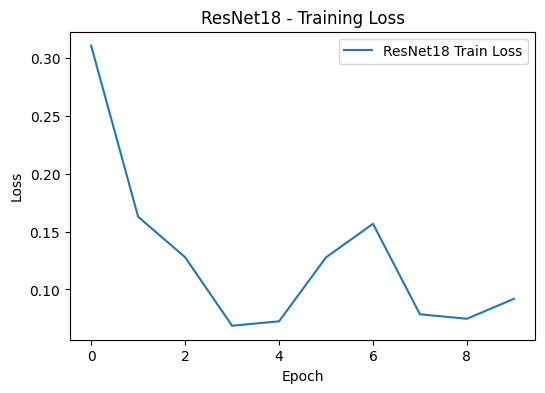

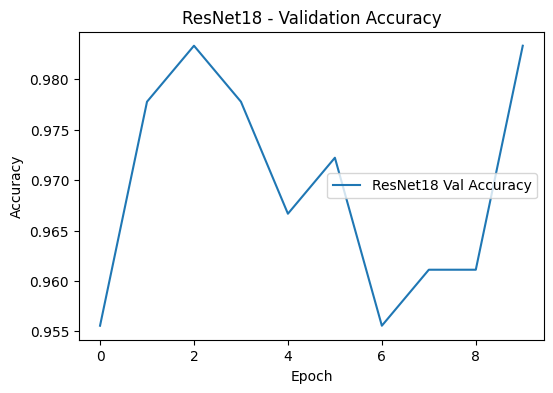

In [8]:
plt.figure(figsize=(6,4))
plt.plot(train_losses_resnet, label="ResNet18 Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 - Training Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(val_accuracies_resnet, label="ResNet18 Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet18 - Validation Accuracy")
plt.legend()
plt.show()

In [9]:
model_resnet.eval()
all_preds_resnet = []
all_labels_resnet = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_resnet(images)
        _, preds = torch.max(outputs, 1)

        all_preds_resnet.extend(preds.cpu().numpy())
        all_labels_resnet.extend(labels.numpy())

print("ResNet18 Classification report:")
print(classification_report(all_labels_resnet, all_preds_resnet, target_names=class_names))

print("ResNet18 Confusion matrix:")
print(confusion_matrix(all_labels_resnet, all_preds_resnet))

ResNet18 Classification report:
                              precision    recall  f1-score   support

          free_parking_space       0.95      1.00      0.97        55
      not_free_parking_space       1.00      0.98      0.99       124
partially_free_parking_space       0.00      0.00      0.00         1

                    accuracy                           0.98       180
                   macro avg       0.65      0.66      0.66       180
                weighted avg       0.98      0.98      0.98       180

ResNet18 Confusion matrix:
[[ 55   0   0]
 [  2 122   0]
 [  1   0   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
